# Exploratory Data Analysis (EDA)

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split,KFold
import matplotlib.pyplot as plt
import seaborn as sns

## Завантаження та обробка даних

In [29]:
df = pd.read_csv('data/tested.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [31]:
df = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Survived"]]
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,34.5,0,0,7.8292,Q,0
1,3,female,47.0,1,0,7.0000,S,1
2,2,male,62.0,0,0,9.6875,Q,0
3,3,male,27.0,0,0,8.6625,S,0
4,3,female,22.0,1,1,12.2875,S,1
...,...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S,0
414,1,female,39.0,0,0,108.9000,C,1
415,3,male,38.5,0,0,7.2500,S,0
416,3,male,NaN,0,0,8.0500,S,0


## Початковий аналіз та обробка даних 
(перевірка на пропущені значення, типи фічерів, їх початкова обробка для подальшого аналізу)

In [32]:
# Перевірка розміру датасету
df.shape

(418, 8)

In [33]:
# Перевірка на наявність пропущених значень
df.isna().sum()

Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
Survived     0
dtype: int64

In [34]:
df["Age"] = df["Age"].fillna(int(df["Age"].mean()))
df.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        1
Embarked    0
Survived    0
dtype: int64

In [35]:
# Дивимось на кількість унікальних значень кожного фічера 
# (таким чином можемо знайти категоріальні фічери та їх кількість унікальних значень)
df.nunique()

Pclass        3
Sex           2
Age          79
SibSp         7
Parch         8
Fare        169
Embarked      3
Survived      2
dtype: int64

In [36]:
# Дивимось на типи даних кожного фічера 
# (object часто означає категоріальний фічер у форматі string, який треба буде обробити)
df.dtypes

Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
Survived      int64
dtype: object

In [37]:
# Переводимо string фічери в числові за допомогою LabelEncoder
sex_encoder = LabelEncoder()
embarked_encoder = LabelEncoder()
df["Sex"] = sex_encoder.fit_transform(df["Sex"])
df["Embarked"] = sex_encoder.fit_transform(df["Embarked"])
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,34.5,0,0,7.8292,1,0
1,3,0,47.0,1,0,7.0000,2,1
2,2,1,62.0,0,0,9.6875,1,0
3,3,1,27.0,0,0,8.6625,2,0
4,3,0,22.0,1,1,12.2875,2,1
...,...,...,...,...,...,...,...,...
413,3,1,30.0,0,0,8.0500,2,0
414,1,0,39.0,0,0,108.9000,0,1
415,3,1,38.5,0,0,7.2500,2,0
416,3,1,30.0,0,0,8.0500,2,0


In [38]:
# Переведення категоріальних фічерів у one-hot encoded
df = pd.get_dummies(df, columns=['Embarked'])
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,Embarked_0,Embarked_1,Embarked_2
0,3,1,34.5,0,0,7.8292,0,False,True,False
1,3,0,47.0,1,0,7.0000,1,False,False,True
2,2,1,62.0,0,0,9.6875,0,False,True,False
3,3,1,27.0,0,0,8.6625,0,False,False,True
4,3,0,22.0,1,1,12.2875,1,False,False,True
...,...,...,...,...,...,...,...,...,...,...
413,3,1,30.0,0,0,8.0500,0,False,False,True
414,1,0,39.0,0,0,108.9000,1,True,False,False
415,3,1,38.5,0,0,7.2500,0,False,False,True
416,3,1,30.0,0,0,8.0500,0,False,False,True


In [39]:
df.dtypes

Pclass          int64
Sex             int32
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Survived        int64
Embarked_0       bool
Embarked_1       bool
Embarked_2       bool
dtype: object

## Побудова графіків для аналізу даних

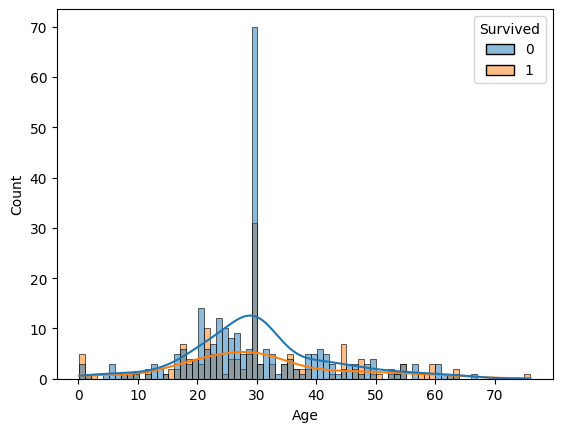

In [40]:
sns.histplot(data=df, x='Age', hue='Survived', binwidth=1, kde=True)
plt.show()

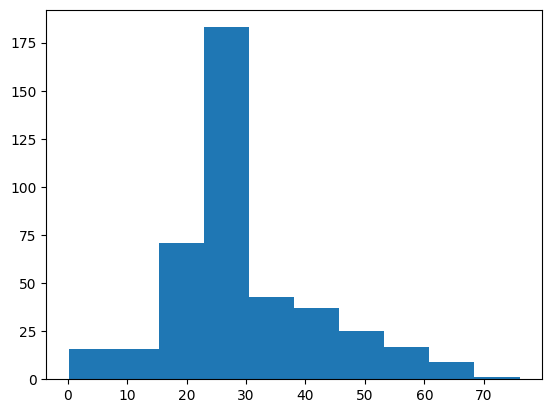

In [41]:
plt.hist(df["Age"], bins=10)
plt.show()

#### Побудова кореляційної матриці фічерів

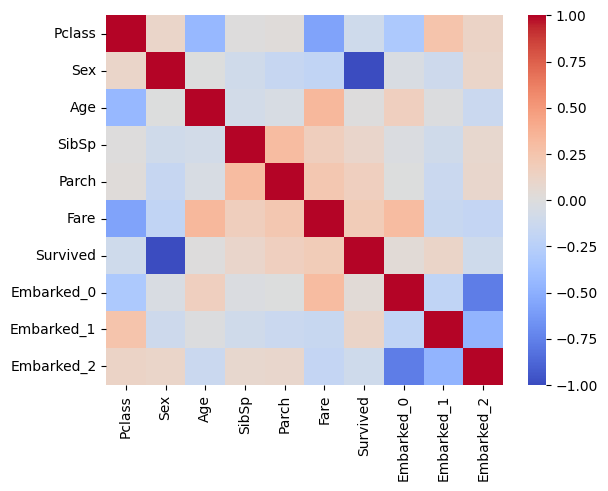

In [17]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

## Розділ даних

In [42]:
x = df.drop(columns=["Survived"])
y = df["Survived"]

###  train/val/test split

In [43]:
x_train, x_val_test, y_train, y_val_test = train_test_split(x, y, test_size=0.4, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=0.5, random_state=42)
x_train.shape, x_val.shape, x_test.shape

((250, 9), (84, 9), (84, 9))

In [44]:
x_train.to_csv("data/processed_data/x_train.csv", index=False)
x_val.to_csv("data/processed_data/x_val.csv", index=False)
x_test.to_csv("data/processed_data/x_test.csv", index=False)

y_train.to_csv("data/processed_data/y_train.csv", index=False)
y_val.to_csv("data/processed_data/y_val.csv", index=False)
y_test.to_csv("data/processed_data/y_test.csv", index=False)